In [112]:
import pandas as pd
import numpy as np

vendas_tech_df = pd.read_csv("vendas_tech.csv", low_memory=False)
gerentes_lojas_df = pd.read_excel("gerentes_lojas.xlsx")
display(gerentes_lojas_df)
display(vendas_tech_df)

,Loja,Gerente,Meta_Mensal
0,São Paulo,Carlos,50000
1,Rio de Janeiro,Fernanda,60000
2,Curitiba,Roberto,45000
3,Belo Horizonte,Juliana,55000
4,Recife,Marcos,48000
5,Porto Alegre,Pedro,42000
6,Salvador,Ana,52000


,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Data_Base
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,2025-01-01
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,NaN
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859,NaN
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343,NaN
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,NaN
...,...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755,NaN
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879,NaN
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160,NaN
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545,NaN


In [113]:
# Analisando as informações do dataframe
display(vendas_tech_df.info())
display(vendas_tech_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            98099 non-null   str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
 7   Data_Base       1 non-null       str    
dtypes: float64(1), int64(2), str(5)
memory usage: 6.1 MB


None

,ID_Pedido,Preco_Unitario,Qtd
count,100100.000000,100100.000000,100100.000000
mean,50004.810180,2000.204595,1.499101
std,28866.872543,1841.050733,1.241605
min,1.000000,40.000000,1.000000
25%,25008.750000,120.000000,1.000000
50%,50004.500000,1200.000000,1.000000
75%,75002.250000,3200.000000,1.000000
max,100000.000000,5500.000000,10.000000


In [114]:
# Excluindo colunas inúteis
analise_df = vendas_tech_df.drop(columns=["Data_Base"])
display(analise_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,NaN,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,RIO DE JANEIRO,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio de Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545


In [115]:
# Preenchendo as linhas vazias

analise_df["Loja"] = analise_df["Loja"].fillna("Online")
display(analise_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ID_Pedido       100100 non-null  int64  
 1   Data            100100 non-null  str    
 2   Loja            100100 non-null  str    
 3   Produto         100100 non-null  str    
 4   Preco_Unitario  100100 non-null  float64
 5   Qtd             100100 non-null  int64  
 6   Cliente         100100 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 5.3 MB


None

In [116]:
# Ajustando o tipo de variável da coluna de data
analise_df["Data"] = pd.to_datetime(analise_df["Data"], format = "%Y-%m-%d")
print(analise_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 100100 entries, 0 to 100099
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   ID_Pedido       100100 non-null  int64         
 1   Data            100100 non-null  datetime64[us]
 2   Loja            100100 non-null  str           
 3   Produto         100100 non-null  str           
 4   Preco_Unitario  100100 non-null  float64       
 5   Qtd             100100 non-null  int64         
 6   Cliente         100100 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(3)
memory usage: 5.3 MB
None


In [117]:
# Padronizando o texto de ambas as tabelas
analise_df["Loja"] = analise_df["Loja"].str.strip()
analise_df["Loja"] = analise_df["Loja"].str.title()

gerentes_lojas_df["Loja"] = gerentes_lojas_df["Loja"].str.strip()
gerentes_lojas_df["Loja"] = gerentes_lojas_df["Loja"].str.title()
display(analise_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
100095,94091,2023-10-20,Porto Alegre,iPhone 14,5500.0,1,Cliente_11755
100096,52883,2024-03-17,Porto Alegre,Notebook Dell,3500.0,2,Cliente_12879
100097,65070,2023-06-19,Belo Horizonte,Smartphone Samsung,2200.0,2,Cliente_8160
100098,94031,2024-06-14,Salvador,iPhone 14,5500.0,2,Cliente_28545


In [118]:
# Removendo duplicata
analise_df = analise_df.drop_duplicates(subset=["ID_Pedido","Loja"])
# subset -> Se o ID_Pedido e a loja se repetiram significa que foi o mesmo pedido então é uma duplicata
display(analise_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377
...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205


#### Criando novas colunas

In [119]:
# Faturamento
analise_df["Faturamento"] = analise_df["Qtd"] * analise_df["Preco_Unitario"]

# Forma de venda
analise_df["Forma_de_Venda"] = np.where(analise_df["Loja"] == "Online", "Online", "Presencial")


In [120]:
# Região
display(analise_df["Loja"].unique())

<StringArray>
[     'São Paulo', 'Belo Horizonte',         'Online', 'Rio De Janeiro',
       'Salvador',         'Recife',       'Curitiba',   'Porto Alegre']
Length: 8, dtype: str

In [121]:
regiao = {
    "Recife": "Nordeste",
    "Salvador": "Nordeste",
    "São Paulo": "Sudeste",
    "Belo Horizonte": "Sudeste",
    "Rio De Janeiro": "Sudeste",
    "Curitiba": "Sul",
    "Porto Alegre": "Sul",
    "Online": "Online"
}
analise_df["Regiao"] = analise_df["Loja"].map(regiao)
display(analise_df)
display(analise_df.isna().sum())# Verificando se alguma linha não foi preenchida

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
0,1,2023-06-08,São Paulo,Mouse Gamer,120.0,1,Cliente_4095,120.0,Presencial,Sudeste
1,2,2023-03-01,Belo Horizonte,iPhone 14,5500.0,1,Cliente_8750,5500.0,Presencial,Sudeste
2,3,2023-02-25,Online,"Monitor 27""",1200.0,1,Cliente_14859,1200.0,Online,Online
3,4,2024-11-19,Rio De Janeiro,Mouse Gamer,120.0,2,Cliente_17343,240.0,Presencial,Sudeste
4,5,2024-01-27,Rio De Janeiro,Smartphone Samsung,2200.0,1,Cliente_23377,2200.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,99996,2023-01-24,São Paulo,Mouse Gamer,120.0,2,Cliente_13732,240.0,Presencial,Sudeste
99996,99997,2024-08-28,Rio De Janeiro,Cabo HDMI,40.0,1,Cliente_25058,40.0,Presencial,Sudeste
99997,99998,2024-03-18,Curitiba,Smartphone Samsung,2200.0,2,Cliente_28864,4400.0,Presencial,Sul
99998,99999,2023-11-04,Porto Alegre,iPhone 14,5500.0,1,Cliente_4205,5500.0,Presencial,Sul


ID_Pedido         0
Data              0
Loja              0
Produto           0
Preco_Unitario    0
Qtd               0
Cliente           0
Faturamento       0
Forma_de_Venda    0
Regiao            0
dtype: int64

### Analisando o banco de dados

In [122]:
analise_df = analise_df.sort_values(by="Data")# Ordenando o dataframe pela data
analise_df = analise_df.reset_index(drop=True)
display(analise_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
0,34750,2023-01-01,Rio De Janeiro,Notebook HP,3200.0,1,Cliente_9014,3200.0,Presencial,Sudeste
1,13699,2023-01-01,Rio De Janeiro,Teclado Mecânico,250.0,1,Cliente_24330,250.0,Presencial,Sudeste
2,81394,2023-01-01,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_9758,250.0,Presencial,Sul
3,251,2023-01-01,São Paulo,Teclado Mecânico,250.0,3,Cliente_22822,750.0,Presencial,Sudeste
4,77068,2023-01-01,Rio De Janeiro,Notebook Dell,3500.0,1,Cliente_554,3500.0,Presencial,Sudeste
...,...,...,...,...,...,...,...,...,...,...
99995,43207,2024-12-30,Belo Horizonte,Notebook Dell,3500.0,2,Cliente_15893,7000.0,Presencial,Sudeste
99996,3183,2024-12-30,Salvador,Mouse Gamer,120.0,1,Cliente_4075,120.0,Presencial,Nordeste
99997,9461,2024-12-30,Porto Alegre,Teclado Mecânico,250.0,1,Cliente_22763,250.0,Presencial,Sul
99998,2793,2024-12-30,Salvador,Notebook Dell,3500.0,1,Cliente_24692,3500.0,Presencial,Nordeste


In [123]:
# Criando novos dataframe com condicionais

# Exportando pedaços da base (Loja em São Paulo)
vendas_sao_paulo_df = analise_df[analise_df["Loja"] == "São Paulo"]
vendas_sao_paulo_df.to_csv("vendas_tech_São_Paulo.csv", index=False,sep=";",encoding="utf-8-sig")

# Exportando as vendas de 2024
vendas_2024_df = analise_df[analise_df["Data"].dt.year == 2024]
vendas_sao_paulo_df.to_csv("vendas_tech_2024.csv", index=False,sep=";",encoding="utf-8-sig")

# Multiplas condições
vendas_notebook_df = analise_df[(analise_df["Regiao"]=="Sul") & (analise_df["Produto"] == "Notebook HP")]
vendas_notebook_df.to_csv("vendas_tech_Notebook.csv", index=False,sep=";",encoding="utf-8-sig")
display(vendas_notebook_df)

,ID_Pedido,Data,Loja,Produto,Preco_Unitario,Qtd,Cliente,Faturamento,Forma_de_Venda,Regiao
64,32100,2023-01-01,Curitiba,Notebook HP,3200.0,1,Cliente_19331,3200.0,Presencial,Sul
90,56682,2023-01-01,Porto Alegre,Notebook HP,3200.0,3,Cliente_25493,9600.0,Presencial,Sul
136,26542,2023-01-02,Curitiba,Notebook HP,3200.0,1,Cliente_20519,3200.0,Presencial,Sul
171,61940,2023-01-02,Curitiba,Notebook HP,3200.0,1,Cliente_21924,3200.0,Presencial,Sul
216,22452,2023-01-02,Porto Alegre,Notebook HP,3200.0,2,Cliente_23682,6400.0,Presencial,Sul
...,...,...,...,...,...,...,...,...,...,...
99832,1811,2024-12-29,Porto Alegre,Notebook HP,3200.0,2,Cliente_12440,6400.0,Presencial,Sul
99854,90821,2024-12-29,Curitiba,Notebook HP,3200.0,1,Cliente_2555,3200.0,Presencial,Sul
99857,81841,2024-12-29,Porto Alegre,Notebook HP,3200.0,1,Cliente_23927,3200.0,Presencial,Sul
99920,41851,2024-12-30,Curitiba,Notebook HP,3200.0,1,Cliente_24536,3200.0,Presencial,Sul


### Análise por agrupamento

In [124]:
# Ranking de faturamento por loja

analise_faturamento_df = analise_df[["Loja", "Faturamento"]].groupby("Loja").sum()
# Soma os faturamentos agrupando por Lojas
analise_faturamento_df = analise_faturamento_df.sort_values(by="Faturamento", ascending=False)
# Ordena os faturamentos de forma decrescente
analise_faturamento_df = analise_faturamento_df.reset_index()
# Torna Loja uma coluna de novo recolocando os indices
analise_faturamento_df["Faturamento"] = (analise_faturamento_df["Faturamento"].map("R$ {:,.2f}".format))
# Formata o texto do faturamento

analise_faturamento_df.to_csv("analise_faturamento.csv", index=False, sep=";",encoding="utf-8-sig")
display(analise_faturamento_df)

,Loja,Faturamento
0,Salvador,"R$ 42,300,610.00"
1,Rio De Janeiro,"R$ 42,294,720.00"
2,Recife,"R$ 42,190,390.00"
3,São Paulo,"R$ 42,090,690.00"
4,Belo Horizonte,"R$ 41,714,890.00"
5,Porto Alegre,"R$ 41,678,460.00"
6,Curitiba,"R$ 41,121,720.00"
7,Online,"R$ 6,080,850.00"


In [125]:
# Ranking de vendas de produtos Online
faturamento_online_df = analise_df[["Produto", "Faturamento"]].groupby("Produto").sum()
faturamento_online_df = faturamento_online_df.sort_values(by = "Faturamento", ascending=False)
faturamento_online_df = faturamento_online_df.reset_index()

faturamento_online_df["Faturamento"] = (faturamento_online_df["Faturamento"].map("R$ {:,.2f}".format))

faturamento_online_df.to_csv("faturamento_online.csv", index=False, sep=";", encoding="utf-8-sig")

display(faturamento_online_df)

,Produto,Faturamento
0,iPhone 14,"R$ 103,510,000.00"
1,Notebook Dell,"R$ 64,599,500.00"
2,Notebook HP,"R$ 60,476,800.00"
3,Smartphone Samsung,"R$ 40,356,800.00"
4,"Monitor 27""","R$ 22,828,800.00"
5,Teclado Mecânico,"R$ 4,695,750.00"
6,Mouse Gamer,"R$ 2,252,520.00"
7,Cabo HDMI,"R$ 752,160.00"


In [126]:
# Análise de ranking por loja e produto

# Quanto cada produto vendeu por Loja
analise_produtos_em_lojas = analise_df[["Loja","Produto","Qtd"]].groupby(["Loja","Produto"], as_index=False).sum()
analise_produtos_em_lojas.to_csv("Análise_da_quantidade_de_produtos_vendidos_por_loja.csv", sep=";", index=False, encoding="utf-8-sig")

# Quanto cada loja vendeu por produto
analise_lojas_em_produtos = analise_df[["Loja","Produto","Qtd"]].groupby(["Produto","Loja"], as_index=False).sum()
analise_lojas_em_produtos.to_csv("Análise_da_quantidade_de_vendas_de_produtos_por_loja.csv", sep=";", index=False, encoding="utf-8-sig")

display(analise_produtos_em_lojas)
display(analise_lojas_em_produtos)


,Loja,Produto,Qtd
0,Belo Horizonte,Cabo HDMI,2636
1,Belo Horizonte,"Monitor 27""",2625
2,Belo Horizonte,Mouse Gamer,2465
3,Belo Horizonte,Notebook Dell,2654
4,Belo Horizonte,Notebook HP,2775
...,...,...,...
59,São Paulo,Notebook Dell,2535
60,São Paulo,Notebook HP,2592
61,São Paulo,Smartphone Samsung,2476
62,São Paulo,Teclado Mecânico,2589


,Produto,Loja,Qtd
0,Cabo HDMI,Belo Horizonte,2636
1,Cabo HDMI,Curitiba,2698
2,Cabo HDMI,Online,403
3,Cabo HDMI,Porto Alegre,2571
4,Cabo HDMI,Recife,2534
...,...,...,...
59,iPhone 14,Porto Alegre,2540
60,iPhone 14,Recife,2652
61,iPhone 14,Rio De Janeiro,2702
62,iPhone 14,Salvador,2671


In [130]:
# Análise de matas de gerentes
meta_df = analise_df[(analise_df["Data"].dt.year == 2023) & (analise_df["Data"].dt.month == 1)]
meta_df = meta_df[["Loja","Faturamento"]].groupby("Loja", as_index = False).sum()

meta_df = meta_df.merge(gerentes_lojas_df, on="Loja", how="left")
# Fiz um left join

meta_df["Bateu_meta"] = np.where((meta_df["Faturamento"] >= meta_df["Meta_Mensal"]), "Sim", "Não")
meta_df.to_csv("Análise_ded_cumprimeto_de_metas.csv", sep=";", index=False, encoding="utf-8-sig")
display(meta_df)

,Loja,Faturamento,Gerente,Meta_Mensal,Bateu_meta
0,Belo Horizonte,1779100.0,Juliana,55000.0,Sim
1,Curitiba,1986920.0,Roberto,45000.0,Sim
2,Online,404570.0,NaN,NaN,Não
3,Porto Alegre,1726640.0,Pedro,42000.0,Sim
4,Recife,1779020.0,Marcos,48000.0,Sim
5,Rio De Janeiro,1736830.0,Fernanda,60000.0,Sim
6,Salvador,1686070.0,Ana,52000.0,Sim
7,São Paulo,1831140.0,Carlos,50000.0,Sim


,Faturamento
Mes-ano,
2023-01,12930290.0
2023-02,11515150.0
2023-03,12516080.0
2023-04,12528900.0
2023-05,12940470.0
2023-06,12455820.0
2023-07,12550990.0
2023-08,12989130.0
2023-09,12118180.0


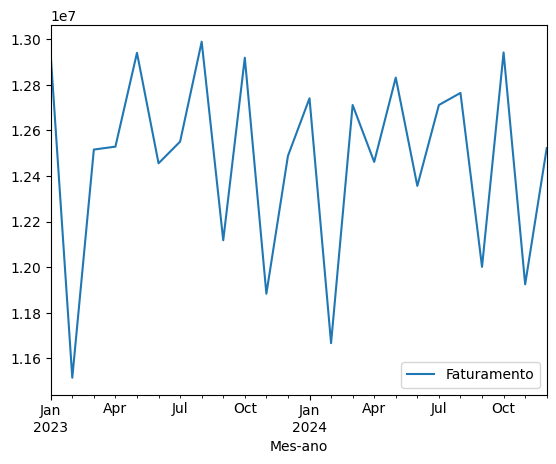

In [132]:
# Análise de faturamento por periodos
analise_df["Mes-ano"] = analise_df["Data"].dt.to_period("M")
vendas_mes_df = analise_df[["Mes-ano","Faturamento"]].groupby("Mes-ano").sum()
vendas_mes_df.plot()
display(vendas_mes_df)